# LangSmith Guide

**What does LangSmith Trace?**
- Input and Output
- All the intermediate steps
- Latency
- Token usage
- Cost
- Error
- Tags
- Metadata
- Feedback

In [ ]:
!uv add langchain-huggingface sentence_transformers hf_xet langsmith faiss-cpu pypdf

In [71]:
import os
import json
import hashlib
import requests
import operator
from pathlib import Path
from langchain import hub
from dotenv import load_dotenv
from langsmith import traceable
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated, List
from langchain_community.vectorstores import FAISS
from langgraph.graph import StateGraph, START, END
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.output_parsers import StrOutputParser
from langchain_community.document_loaders import PyPDFLoader
from langchain.agents import create_react_agent, AgentExecutor
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.runnables import RunnableParallel, RunnablePassthrough, RunnableLambda

load_dotenv()

True

## Usecase: Simple Langchain Chaining


The interesting part about LangSmith is, you don't need to add any extra code to trace your Langchain applications. Just set the environment variables and you are good to go!

In [2]:
# Simple one-line prompt
prompt = PromptTemplate.from_template("{question}")

In [3]:
llm = ChatGroq(
    api_key = os.getenv("GROQ_API_KEY"),
    model = "llama-3.1-8b-instant"
)
parser = StrOutputParser()

In [4]:
# Chain: prompt --> llm --> parser
chain = prompt | llm | parser

In [5]:
result = chain.invoke({"question": "What is the capital of Peru?"})
result

'The capital of Peru is Lima.'

## Usecase: Sequential Chain

In [6]:
prompt1 = PromptTemplate(
    template = "Generate a detailed report on {topic}.",
    input_variables = ["topic"]
)

prompt2 = PromptTemplate(
    template = "Generate a 5 pointer summary from the following text \n {text}",
    input_variables = ["text"]
)

In [9]:
chain = prompt1 | llm | parser | prompt2 | llm | parser

# You can also assign different tags and metadata for your trace in LangSmith
config = {
    "run_name": "Report Generation and Summarization Chain",
    "tags": ["llm app", "report generation", "summarization"],
    "metadata": {"model1": "gpt-40-mini", "model2": "llama-3.1-70b-instant", "model1_temperature": 0.7, "model2_temperature": 0.3, "parser": "StrOutputParser"}
}

result = chain.invoke({"topic": "Stock market crash till now"}, config=config)
print(result)

Here's a 5-pointer summary of the stock market crash report:

1. **The Stock Market Has Experienced Multiple Crashes**: Throughout its history, the stock market has faced numerous crashes, each with unique causes and consequences, resulting in significant declines in stock prices and a loss of investor confidence.

2. **Notable Crashes Include the 1929 Great Depression, 1987 Black Monday, and 2008 Global Financial Crisis**: These crashes were triggered by various factors, such as economic downturns, global events, and market speculation, and had a devastating impact on the global economy and the stock market.

3. **Understanding Causes and Consequences is Crucial**: Investors and policymakers must understand the underlying causes and consequences of stock market crashes to prepare for and mitigate their impact. This includes maintaining a diversified portfolio, implementing risk management strategies, and monitoring market trends.

4. **Diversification, Risk Management, and Long-Term P

## Usecase: RAG Application

**Key Points:**
- For the Vector Store creation stage, the LangSmith tracing is not supported yet. For that, you have to define the `@traceable` decorator around the functions.
    - To this decorator, you can pass `name`, `tags` and `metadata` parameters to trace better.

In [24]:
## Load the PDF document

PDF_FILE_PATH = Path(r"C:\Users\SayanRoy\Documents\Agentic AI Guide\02-LangGraph Tutorial\CampusX\langsmith-masterclass\islr.pdf")
INDEX_ROOT = Path(".indices")
INDEX_ROOT.mkdir(exist_ok=True)

@traceable(name = "load_pdf", tags=["pdf", "loader"], metadata={"loader": "PyPDFLoader"})
def load_pdf(file_path):
    return PyPDFLoader(str(file_path)).load()

In [25]:
# Create chunks of the document
@traceable(name = "split_documents", tags=["text-splitter"], metadata={"chunk_size": 1000, "chunk_overlap": 150})
def split_documents(docs, chunk_size=1000, chunk_overlap=150):
    return RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=chunk_overlap).split_documents(docs)

In [26]:
# embedding + indexing
@traceable(name = "build_vector_store", tags=["vector_store", "faiss", "embedding"], metadata={"embedding_model": "sentence-transformers/all-mpnet-base-v2"})
def build_vector_store(splits, model_name: str = "sentence-transformers/all-mpnet-base-v2"):
    return FAISS.from_documents(splits, HuggingFaceEmbeddings(model_name=model_name))

In [27]:
def _file_fingerprint(path: str) -> dict:
    p = Path(path)
    h = hashlib.sha256()
    with p.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return {"sha256": h.hexdigest(), "size": p.stat().st_size, "mtime": int(p.stat().st_mtime)}

def _index_key(pdf_path: str, chunk_size: int, chunk_overlap: int, embed_model_name: str) -> str:
    meta = {
        "pdf_fingerprint": _file_fingerprint(pdf_path),
        "chunk_size": chunk_size,
        "chunk_overlap": chunk_overlap,
        "embedding_model": embed_model_name,
        "format": "v1",
    }
    return hashlib.sha256(json.dumps(meta, sort_keys=True).encode("utf-8")).hexdigest()

In [28]:
@traceable(name = "load_index", tags = ["index"])
def load_index_run(index_dir: Path, embed_model_name: str):
    embedding_model = HuggingFaceEmbeddings(model_name = embed_model_name)
    return FAISS.load_local(
        folder_path=str(index_dir),
        embeddings=embedding_model,
        allow_dangerous_deserialization=True
    )

In [29]:
@traceable(name = "build_index", tags = ["index"])
def build_index_run(pdf_path: Path, index_dir: Path, chunk_size: int, chunk_overlap: int, embed_model_name: str):
    docs = load_pdf(pdf_path)
    splits = split_documents(docs, chunk_size=chunk_size, chunk_overlap=chunk_overlap)
    vector_store = build_vector_store(splits, embed_model_name)
    index_dir.mkdir(parents=True, exist_ok=True)
    vector_store.save_local(folder_path=str(index_dir))
    (index_dir / "meta.json").write_text(json.dumps({
        "pdf_path": os.path.abspath(pdf_path),
        "chunk_size": chunk_size,
        "chunk_overlap": chunk_overlap,
        "embedding_model": embed_model_name,
    }, indent = 4))
    return vector_store

In [30]:
# Dispatcher (not traced)
def load_or_build_index(
    pdf_path: str,
    chunk_size: int = 1000,
    chunk_overlap: int = 150,
    embed_model_name: str = "text-embedding-3-small",
    force_rebuild: bool = False,
):
    key = _index_key(pdf_path, chunk_size, chunk_overlap, embed_model_name)
    index_dir = INDEX_ROOT / key
    cache_hit = index_dir.exists() and not force_rebuild
    if cache_hit:
        return load_index_run(index_dir, embed_model_name)
    else:
        return build_index_run(pdf_path, index_dir, chunk_size, chunk_overlap, embed_model_name)

In [31]:
# prompting
llm = ChatGroq(api_key = os.getenv("GROQ_API_KEY"), model = "llama-3.1-8b-instant")

prompt = ChatPromptTemplate.from_messages([
    ("system", "Answer ONLY from the provided context. If not found, say you don't know."),
    ("human", "Question: {question}\n\nContext:\n{context}")
])

In [35]:
def format_docs(docs):
    return "\n\n".join(d.page_content for d in docs)

@traceable(name = "setup_pipeline", tags = ["pipeline"])
def setup_pipeline(pdf_path: Path, chunk_size: int = 1000, chunk_overlap: int = 150, embed_model_name: str = "sentence-transformers/all-mpnet-base-v2", force_rebuild=False):
    return load_or_build_index(
        pdf_path=pdf_path,
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        embed_model_name=embed_model_name,
        force_rebuild=force_rebuild
    )

In [36]:
@traceable(name="pdf_rag_full_run")
def setup_pipeline_and_query(
    pdf_path: str,
    question: str,
    chunk_size: int = 1000,
    chunk_overlap: int = 150,
    embed_model_name: str = "sentence-transformers/all-mpnet-base-v2",
    force_rebuild: bool = False,
):
    vectorstore = setup_pipeline(pdf_path, chunk_size, chunk_overlap, embed_model_name, force_rebuild)
    retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 4})

    parallel = RunnableParallel({
        "context": retriever | RunnableLambda(format_docs),
        "question": RunnablePassthrough(),
    })
    chain = parallel | prompt | llm | StrOutputParser()

    return chain.invoke(
        question,
        config={"run_name": "pdf_rag_query", "tags": ["qa"], "metadata": {"k": 4}}
    )

In [39]:
# Ask questions
print("PDF RAG ready. Ask a question (or Ctrl+C to exit).")
q = input("\nQ: ")
print("\nQ:", q)
ans = setup_pipeline_and_query(PDF_FILE_PATH, q)
print("\nA:", ans)

PDF RAG ready. Ask a question (or Ctrl+C to exit).

Q: What is GLM?

A: GLM stands for Generalized Linear Models.


## Usecase: ReAct Agent using Langchain

In [64]:
llm = ChatGroq(api_key = os.getenv("GROQ_API_KEY"), model = "llama-3.3-70b-versatile")

In [65]:
@tool
def get_weather_data(city: str) -> str:
    """
    This function fetches the current weather data for a given city
    """
    url = f'https://api.weatherstack.com/current?access_key={os.getenv("WEATHER_API_KEY")}&query={city}'

    response = requests.get(url)

    return response.json()

In [66]:
# Pull the ReAct prompt from LangChain Hub
prompt = hub.pull("hwchase17/react")  # pulls the standard ReAct agent prompt

# Create the ReAct agent manually with the pulled prompt
search_tool = DuckDuckGoSearchRun()
agent = create_react_agent(
    llm=llm,
    tools=[search_tool, get_weather_data],
    prompt=prompt
)

# Wrap it with AgentExecutor
agent_executor = AgentExecutor(
    agent=agent,
    tools=[search_tool, get_weather_data],
    verbose=True,
    max_iterations=10,
    handle_parsing_errors=True
)

In [67]:
# What is the release date of Dhadak 2?
# What is the current temp of gurgaon
# Identify the birthplace city of Kalpana Chawla (search) and give its current temperature.

# Step 5: Invoke
response = agent_executor.invoke({"input": "Identify the birthplace city of Kalpana Chawla (search) and give its current temperature."})
print(response)



> Entering new AgentExecutor chain...
Thought: To answer this question, I need to first find the birthplace city of Kalpana Chawla and then get the current temperature of that city.

Action: duckduckgo_search
Action Input: Kalpana Chawla birthplace city

c:\Users\SayanRoy\Documents\Agentic AI Guide\.venv\lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


No good DuckDuckGo Search Result was foundThought: The initial search did not yield a satisfactory result. I should try rephrasing the search query to get more accurate information about Kalpana Chawla's birthplace.

Action: duckduckgo_search
Action Input: Kalpana Chawla hometown

c:\Users\SayanRoy\Documents\Agentic AI Guide\.venv\lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


Kalpana Ranjani (5 October 1965 – 25 January 2016), better known mononymously as Kalpana, was an Indian actress who appeared in South Indian films, predominantly in Malayalam and Tamil. Kalpana Chawla (born March 17, 1962, Karnal [now in Haryana], India —died February 1, 2003, in flight, over Louisiana and Texas, U.S.) was an Indian-born American astronaut and the first … Kalpana Ranjani, mononymously known as Kalpana, is an Indian actress known for her comic roles in South Indian film industries and more particularly in Malayalam cinema. At the 60th National... Mar 18, 2025 · Kalpana Chawla made history as the first Indian-origin woman in space, inspiring millions with her passion for exploration. Her tragic loss in the 2003 Columbia disaster didn't end … Jul 18, 2024 · Kalpana, born Kalpana Priyadarsini, hailed from a family of artistes. While her parents, Chavara VP Nair and Vijayalakshmi, were theatre artistes, her sisters, Kala Ranjini and Kavitha …Thought: I was able to find that

## Usecase: LangGraph with LangSmith

In [ ]:
llm = ChatGroq(api_key = os.getenv("GROQ_API_KEY"), model = "llama-3.1-8b-instant")

In [ ]:
# Structured schema & model
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback for the essay")
    score: int = Field(description="Score out of 10 as a whole number", ge=0, le=10)

structured_llm = llm.with_structured_output(EvaluationSchema)

In [ ]:
# langgraph state
class UPSCState(TypedDict, total=False):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[List[int], operator.add]  # merges parallel lists
    avg_score: float

In [73]:
# Define the node functions
@traceable(name="evaluate_language_fn", tags=["dimension:language"], metadata={"dimension": "language"})
def evaluate_language(state: UPSCState):
    prompt = (
        "Evaluate the language quality of the following essay and provide feedback "
        "and assign a score out of 10.\n\n" + state["essay"]
    )
    out = structured_llm.invoke(prompt)
    return {"language_feedback": out.feedback, "individual_scores": [out.score]}

@traceable(name="evaluate_analysis_fn", tags=["dimension:analysis"], metadata={"dimension": "analysis"})
def evaluate_analysis(state: UPSCState):
    prompt = (
        "Evaluate the depth of analysis of the following essay and provide feedback "
        "and assign a score out of 10.\n\n" + state["essay"]
    )
    out = structured_llm.invoke(prompt)
    return {"analysis_feedback": out.feedback, "individual_scores": [out.score]}

@traceable(name="evaluate_thought_fn", tags=["dimension:clarity"], metadata={"dimension": "clarity_of_thought"})
def evaluate_thought(state: UPSCState):
    prompt = (
        "Evaluate the clarity of thought of the following essay and provide feedback "
        "and assign a score out of 10.\n\n" + state["essay"]
    )
    out = structured_llm.invoke(prompt)
    return {"clarity_feedback": out.feedback, "individual_scores": [out.score]}

@traceable(name="final_evaluation_fn", tags=["aggregate"])
def final_evaluation(state: UPSCState):
    prompt = (
        "Based on the following feedback, create a summarized overall feedback.\n\n"
        f"Language feedback: {state.get('language_feedback','')}\n"
        f"Depth of analysis feedback: {state.get('analysis_feedback','')}\n"
        f"Clarity of thought feedback: {state.get('clarity_feedback','')}\n"
    )
    overall = llm.invoke(prompt).content
    scores = state.get("individual_scores", []) or []
    avg = (sum(scores) / len(scores)) if scores else 0.0
    return {"overall_feedback": overall, "avg_score": avg}

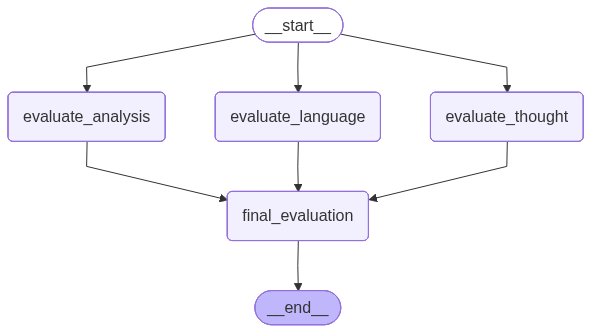

In [74]:
# build the graph
graph = StateGraph(UPSCState)

graph.add_node("evaluate_language", evaluate_language)
graph.add_node("evaluate_analysis", evaluate_analysis)
graph.add_node("evaluate_thought", evaluate_thought)
graph.add_node("final_evaluation", final_evaluation)

# Fan-out → join
graph.add_edge(START, "evaluate_language")
graph.add_edge(START, "evaluate_analysis")
graph.add_edge(START, "evaluate_thought")
graph.add_edge("evaluate_language", "final_evaluation")
graph.add_edge("evaluate_analysis", "final_evaluation")
graph.add_edge("evaluate_thought", "final_evaluation")
graph.add_edge("final_evaluation", END)

app = graph.compile()
app

In [75]:
essay2 = """India and AI Time

Now world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.

India have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.

In farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.

But problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.

One more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.

India must all people together – govern, school, company and normal people. We teach AI and make sure AI not bad. Also talk to other country and learn from them.

If India use AI good way, we become strong, help poor and make better life. But if only rich use AI, and poor no get, then big bad thing happen.

So, in short, AI time in India have many hope and many danger. We must go right road. AI must help all people, not only some. Then India grow big and world say "good job India".
"""

result = app.invoke(
    {"essay": essay2},
    config={
        "run_name": "evaluate_upsc_essay",  # becomes root run name
        "tags": ["essay", "langgraph", "evaluation"],
        "metadata": {
            "essay_length": len(essay2),
            "model": "gpt-4o-mini",
            "dimensions": ["language", "analysis", "clarity"],
        },
    },
)

print("\n=== Evaluation Results ===")
print("Language feedback:\n", result.get("language_feedback", ""), "\n")
print("Analysis feedback:\n", result.get("analysis_feedback", ""), "\n")
print("Clarity feedback:\n", result.get("clarity_feedback", ""), "\n")
print("Overall feedback:\n", result.get("overall_feedback", ""), "\n")
print("Individual scores:", result.get("individual_scores", []))
print("Average score:", result.get("avg_score", 0.0))


=== Evaluation Results ===
Language feedback:
 The essay discusses the potential of Artificial Intelligence (AI) in India and its impact on various sectors. However, the language quality is poor due to numerous grammatical errors, simplistic vocabulary, and a lack of coherence. The writer's ideas are not well-organized, and the text lacks proper sentence structure and punctuation. Despite the effort to highlight the benefits and challenges of AI in India, the essay's language quality detracts from its overall message. To improve, the writer should focus on developing their writing skills, including grammar, vocabulary, and sentence structure. 

Analysis feedback:
 The essay provides a basic overview of the potential benefits and drawbacks of AI in India, but lacks depth and nuance in its analysis. The writing is simple and often relies on vague statements, such as 'India can go top' or 'AI must help all people.' The essay could benefit from more specific examples, data, and expert opi